<a href="https://colab.research.google.com/github/juniti-y/RLseminar/blob/main/RLex02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# モジュールの呼び出し

In [2]:
# numpyモジュールの呼び出し
import numpy as np

# matplotlibモジュールの呼び出し (%matplotlib行は環境に応じて変更すること)
import matplotlib.pyplot as plt

# 環境クラスを生成

## T迷路環境をクラスとして定義

In [3]:
class Tmaze():
    """
    T迷路の環境を定義するクラス
    [メンバー変数]
    - num_state: 状態の総数
    - num_action: 行動の総数
    - state: 各時刻で訪問している状態のインデクス
      - state = 0 -> J1
      - state = 1 -> J2
      - state = 2 -> J3
      - state = 3 -> G
      にそれぞれ対応
    """
    # 状態の総数を表す定数
    num_state = 4
    # 行動の総数を表す定数
    num_action = 2
    # 現在の状態を表す変数
    state = 0

    def __init__(self):
        """
        コンストラクタ
        """
        pass

    def show_state(self):
        """
        現在の状態を標準出力するメソッド関数
        """
        print(self.state)

    def get_env_config(self):
        """
        環境設定（状態数, 行動数）を取得するためのメソッド関数
        """
        return self.num_state, self.num_action

    def init_state(self):
        """
        状態を初期化（初期状態に戻す）メソッド関数
        """
        self.state = 0
        reward = None
        return reward, self.state

    # 選択した行動に従って状態を遷移させるメソッド関数
    # action = 0: 左
    # action = 1: 右
    def move_state(self, action):
        """
        選択した行動 action に従って状態を遷移させるメソッド関数
        [入力引数]
        - action: 行動のインデクス
          - action = 0: 左
          - action = 1: 右
        """
        if self.state == 0:
            if action == 0:
                self.state = 1
                reward = -1.0
            else:
                self.state = 2
                reward = 0.0
        elif self.state == 1:
            if action == 0:
                self.state = 3
                reward = 10.0
            else:
                self.state = 3
                reward = 0.0
        elif self.state ==2:
            if action == 0:
                self.state = 3
                reward = 2.0
            else:
                self.state = 3
                reward = -10.0
        return reward, self.state

    def reach_goal(self):
        """
        ゴールに到達したか否かを伝えるメソッド関数
        [返り値]
            - True: ゴールに到達
            - False: ゴールに未到達
        """
        if self.state == 3:
            return True
        else:
            return False

## ダンジョン環境をクラスとして定義

In [4]:
class Dungeon(Tmaze):
    def __init__(self, config_file):
        """
        コンストラクタ
        """
        # CSV形式で保存されているマップ情報を表示する
        self.map_info = np.loadtxt(config_file, delimiter=',', dtype = 'int64')
        # マップのサイズを読み取る
        [self.vsize, self.hsize] =  self.map_info.shape
        # 状態の総数を表す定数
        self.num_state = self.vsize * self.hsize
        # 行動の総数を表す定数
        self.num_action = 4
        # マップ情報から初期状態位置を取得を取得する
        match_idx = np.where(self.map_info.ravel() == 2)
        self.state0 = match_idx[0][0]
        # マップ情報からゴール状態位置を取得を取得する
        match_idx = np.where(self.map_info.ravel() == 3)
        self.stateG = match_idx[0][0]

        # 現在の状態を仮初期化
        self.init_state()

    def init_state(self):
        """
        状態を初期化（初期状態に戻す）メソッド関数
        """
        # 現在の状態を初期状態に変更する
        self.state = self.state0
        # 状態番号からグリッド上の横位置へと変換
        self.h_loc = self.state % self.hsize
        # 状態番号からグリッド上の縦位置へと変換
        self.v_loc = self.state // self.hsize
        # 報酬を欠損値にしておく
        reward = None

        return reward, self.state

    def move_state(self, action):
        """
        選択した行動 action に従って状態を遷移させるメソッド関数
        [入力引数]
        - action: 行動のインデクス
          - action = 0: 上
          - action = 1: 右
          - action = 2: 下
          - action = 3: 左
        """
        if action == 0:
            ii = self.v_loc - 1
            jj = self.h_loc
            if ii < 0:
                ii = ii + 1
            elif self.map_info[ii][jj] == 0:
                ii = ii + 1
        elif action == 1:
            ii = self.v_loc
            jj = self.h_loc + 1
            if jj == self.hsize:
                jj = jj -1
            elif self.map_info[ii][jj] == 0:
                jj = jj -1
        elif action == 2:
            ii = self.v_loc + 1
            jj = self.h_loc
            if ii == self.vsize:
                ii = ii - 1
            elif self.map_info[ii][jj] == 0:
                ii = ii - 1
        elif action == 3:
            ii = self.v_loc
            jj = self.h_loc - 1
            if jj < 0:
                jj = jj + 1
            elif self.map_info[ii][jj] == 0:
                jj = jj + 1
        self.state = ii * self.hsize + jj
        self.v_loc = ii
        self.h_loc = jj

        if self.reach_goal():
            reward = 0
        else:
            reward = -1

        return reward, self.state


    def reach_goal(self):
        """
        ゴールに到達したか否かを伝えるメソッド関数
        [返り値]
            - True: ゴールに到達
            - False: ゴールに未到達
        """
        if self.state == self.stateG:
            return True
        else:
            return False

    def print_map_info(self):
        """
        mapの情報を標準出力する
        """
        A = self.map_info.copy()
        A[self.v_loc][self.h_loc] = 8
        print(A)
        return

    def draw_map_info(self, fig):
        """
        mapの情報をグリッド状に表示する
        """
        A = self.map_info.copy()
        A[self.v_loc][self.h_loc] = 8
        fig.clear()
        ax1 = fig.add_subplot(1,1,1)
        ax1.imshow(A, interpolation='nearest', vmin=0, vmax=8, cmap='jet')
        plt.pause(0.02)
        plt.show()
        return

    def draw_value_info(self, fig, Q):
        """
        価値関数の情報をmap上にスーパーインポーズ
        """
        A = np.max(agent1.Q, axis=1)
        match_idx = np.where(self.map_info.ravel() == 0)
        A[match_idx] = np.nan
        B = A.reshape([self.vsize, self.hsize])

        fig.clear()
        ax1 = fig.add_subplot(1,1,1)
        ax1.imshow(B, interpolation='nearest', cmap='jet')
        plt.pause(0.02)
        plt.show()
        return

# エージェントクラスを作成

In [5]:
## Q学習エージェントをクラスとして定義

In [6]:
class Qagent():
    """
    Q学習エージェントを定義するクラス
    """

    def __init__(self, num_state=1, num_action=1):
        """
        コンストラクタ
        [入力引数]
        - num_state: 環境の状態数 (default = 1)
        - num_action: 選択可能な行動数 (default = 1)
        """
        self.num_state = num_state
        self.num_action = num_action
        self.Q = np.zeros((num_state, num_action))
        return

    def set_meta_parameter(self, alpha = 0.1, beta = 1, gamma = 0.99):
        """
        メタパラメータ（エージェントの個性）を設定するメソッド関数
        """
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        return

    def reset_memory(self):
        """
        過去の状態・行動の履歴をリセットする
        """
        self.s0 = None
        self.a0 = None
        return

    def select_action(self, state):
        """
        与えられた状態に対して行動を選択するメソッド関数（方策関数）
        """
        # 行動選択に必要な変数の取得
        Q = self.Q
        beta = self.beta
        s = state

        # \pi(s,a) = \Pr(a|s) ~ exp[beta * Q(s,a)] を計算
        logp = self.beta * self.Q[state,:]
        max_logp = np.max(logp)
        un_p = np.exp(logp - max_logp)
        prob = un_p/sum(un_p)

        # \Pr(a|s)にしたがってaction aをサンプリング
        action = np.random.choice(self.num_action, 1, p=prob)
        a = action[0]
        return a

    def update_value(self, rwd, state, action):
        """
        与えられた状態に対して行動を選択するメソッド関数（方策関数）
        """
        # 学習や行動選択に必要な変数の取得
        Q = self.Q
        s0 = self.s0
        a0 = self.a0
        r1 = rwd
        s1 = state
        a1 = action
        alpha = self.alpha
        gamma = self.gamma

        # 行動価値関数の学習（1ステップ前の状態が観測できているときのみ）
        if self.s0 != None:
            max_q = np.max(Q[s1,:])
            delta = r1 + gamma * max_q - Q[s0,a0]
            Q[s0,a0] = Q[s0,a0] + alpha * delta
            self.Q = Q

        # 過去の状態・行動の履歴を更新
        self.s0 = s1
        self.a0 = a1

        return

    def print_action_value(self):
        """
        現在の行動価値関数を標準出力するメソッド関数
        """
        print(self.Q)
        return

    def draw_action_value(self):
        """
        現在の行動価値関数をヒートマップ表示するメソッド関数
        """
        plt.figure(2)
        plt.imshow(self.Q,interpolation='nearest',cmap='jet')
        plt.pause(0.05)
        plt.show()


## SARSAエージェントをクラスとして定義

In [7]:
class SARSAagent(Qagent):
    """
    SARSAエージェントを定義するクラス
    """

    def update_value(self, rwd, state, action):
        """
        与えられた状態に対して行動を選択するメソッド関数（方策関数）
        """
        # 学習や行動選択に必要な変数の取得
        Q = self.Q
        s0 = self.s0
        a0 = self.a0
        r1 = rwd
        s1 = state
        a1 = action
        alpha = self.alpha
        gamma = self.gamma

        # 行動価値関数の学習（1ステップ前の状態が観測できているときのみ）
        if self.s0 != None:
            next_q = np.max(Q[s1,a1])
            delta = r1 + gamma * next_q - Q[s0,a0]
            Q[s0,a0] = Q[s0,a0] + alpha * delta
            self.Q = Q

        # 過去の状態・行動の履歴を更新
        self.s0 = s1
        self.a0 = a1

        return

# 強化学習デモプログラム

## Q学習エージェントでT迷路課題を解くプログラム本体

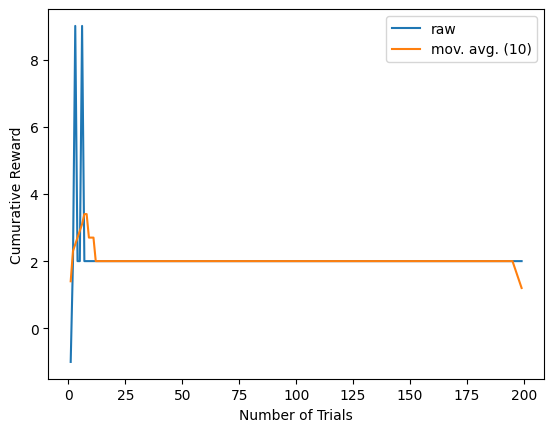

In [8]:
# 最大トライアル数を設定
MaxTrials = 200

# 1トライアルあたりの最大ステップ数（行動選択回数）を設定
MaxSteps = 100

# 環境のオブジェクトを生成
env1 = Tmaze()

# 環境設定を取得する
[num_state, num_action] = env1.get_env_config()

# 学習エージェントオブジェクトを生成
agent1 = Qagent(num_state, num_action)

# 学習エージェントのメタパラメータを設定
agent1.set_meta_parameter(alpha=0.1, beta=5.0, gamma=1.0)

# 各トライアルに獲得した累積報酬を格納する変数を初期化
cum_rwd = np.zeros(MaxTrials)
# トライアルをMaxTrials回くり返す
for trial in range(MaxTrials):
    # 過去の状態・行動履歴をリセットする
    agent1.reset_memory()
    # 環境を初期状態に戻し、その状態を取得する
    [rwd, state] = env1.init_state()
    # ゴール状態に到達するまで以下をくり返す
    for step in range(MaxSteps):
        # ゴール状態に到達できたら、価値関数の更新のみ行う
        if env1.reach_goal():
            agent1.update_value(rwd, state, action)
            break
        # エージェントに現在の状態を伝えて、行動を選択させる
        action = agent1.select_action(state)
        # エージェントの価値関数を更新
        agent1.update_value(rwd, state, action)
        # 選択した行動を環境に出力し、次の状態に遷移させる
        [rwd, state] = env1.move_state(action)
        # 得られた報酬を累積する
        cum_rwd[trial] = cum_rwd[trial] + rwd
# トライアル終了後に累積報酬の推移をグラフ表示
plt.figure(1)
plt.clf()
plt.plot(range(1,trial+1), cum_rwd[0:trial], label = 'raw')
if trial > 20:
    cum_rwd_mvavg =  np.convolve(cum_rwd[0:trial], np.ones(10)/10, mode='same')
    plt.plot(range(1,trial+1), cum_rwd_mvavg, label = 'mov. avg. (10)')
    plt.xlabel('Number of Trials')
    plt.ylabel('Cumurative Reward')
    plt.legend()
    plt.pause(0.05)
    plt.show()

### 学習後の価値関数を文字列で表示

In [9]:
agent1.print_action_value()

[[-0.171       1.99999996]
 [ 1.9         0.        ]
 [ 2.          0.        ]
 [ 0.          0.        ]]


### 学習後の価値関数をヒートマップで表示

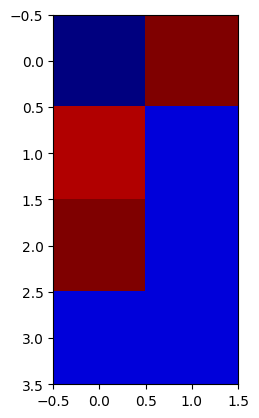

In [10]:
agent1.draw_action_value()

## SARSAエージェントでT迷路課題を解くプログラム本体

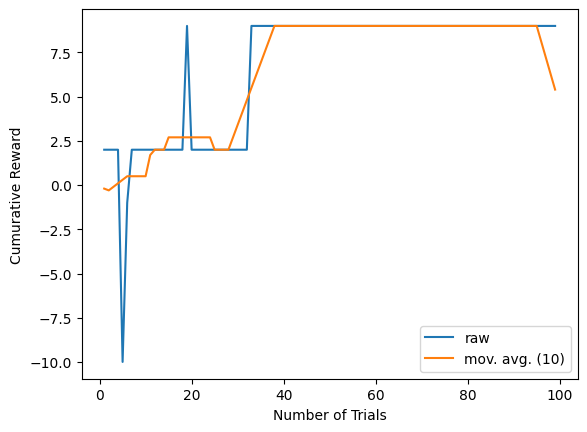

In [11]:
# 最大トライアル数を設定
MaxTrials = 100

# 1トライアルあたりの最大ステップ数（行動選択回数）を設定
MaxSteps = 100

# 環境のオブジェクトを生成
env1 = Tmaze()

# 環境設定を取得する
[num_state, num_action] = env1.get_env_config()

# 学習エージェントオブジェクトを生成
agent1 = SARSAagent(num_state, num_action)

# 学習エージェントのメタパラメータを設定
agent1.set_meta_parameter(alpha=1.0, beta=1.0, gamma=1.0)

# 各トライアルに獲得した累積報酬を格納する変数を初期化
cum_rwd = np.zeros(MaxTrials)
# トライアルをMaxTrials回くり返す
for trial in range(MaxTrials):
    # 過去の状態・行動履歴をリセットする
    agent1.reset_memory()
    # 環境を初期状態に戻し、その状態を取得する
    [rwd, state] = env1.init_state()
    # ゴール状態に到達するまで以下をくり返す
    for step in range(MaxSteps):
        # ゴール状態に到達できたら、価値関数の更新のみ行う
        if env1.reach_goal():
            agent1.update_value(rwd, state, action)
            break
        # エージェントに現在の状態を伝えて、行動を選択させる
        action = agent1.select_action(state)
        # エージェントの価値関数を更新
        agent1.update_value(rwd, state, action)
        # 選択した行動を環境に出力し、次の状態に遷移させる
        [rwd, state] = env1.move_state(action)
        # 得られた報酬を累積する
        cum_rwd[trial] = cum_rwd[trial] + rwd
# トライアル終了後に累積報酬の推移をグラフ表示
plt.figure(1)
plt.clf()
plt.plot(range(1,trial+1), cum_rwd[0:trial], label = 'raw')
if trial > 20:
    cum_rwd_mvavg =  np.convolve(cum_rwd[0:trial], np.ones(10)/10, mode='same')
    plt.plot(range(1,trial+1), cum_rwd_mvavg, label = 'mov. avg. (10)')
    plt.xlabel('Number of Trials')
    plt.ylabel('Cumurative Reward')
    plt.legend()
    plt.pause(0.05)
    plt.show()

### 学習後の価値関数を文字列で表示

In [12]:
agent1.print_action_value()

[[  9.   2.]
 [ 10.   0.]
 [  2. -10.]
 [  0.   0.]]


### 学習後の価値関数をヒートマップで表示

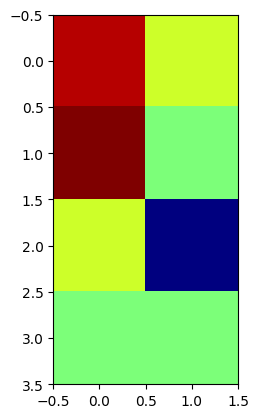

In [13]:
agent1.draw_action_value()

## Q学習エージェントでダンジョンを解くプログラム

trial =  20  cum_rwd =  -100.0
trial =  40  cum_rwd =  -100.0
trial =  60  cum_rwd =  -100.0
trial =  80  cum_rwd =  -100.0
trial =  100  cum_rwd =  -100.0
trial =  120  cum_rwd =  -86.0
trial =  140  cum_rwd =  -89.0
trial =  160  cum_rwd =  -100.0
trial =  180  cum_rwd =  -100.0
trial =  200  cum_rwd =  -37.0
trial =  220  cum_rwd =  -42.0
trial =  240  cum_rwd =  -30.0
trial =  260  cum_rwd =  -29.0
trial =  280  cum_rwd =  -28.0
trial =  300  cum_rwd =  -28.0
trial =  320  cum_rwd =  -28.0
trial =  340  cum_rwd =  -28.0
trial =  360  cum_rwd =  -28.0
trial =  380  cum_rwd =  -28.0
trial =  400  cum_rwd =  -28.0
trial =  420  cum_rwd =  -28.0
trial =  440  cum_rwd =  -28.0
trial =  460  cum_rwd =  -28.0
trial =  480  cum_rwd =  -28.0
trial =  500  cum_rwd =  -28.0
trial =  520  cum_rwd =  -28.0
trial =  540  cum_rwd =  -28.0
trial =  560  cum_rwd =  -28.0
trial =  580  cum_rwd =  -28.0
trial =  600  cum_rwd =  -28.0
trial =  620  cum_rwd =  -28.0
trial =  640  cum_rwd =  -28.0
trial

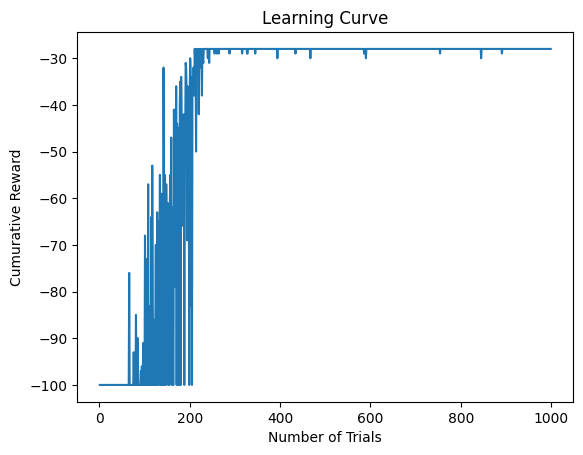

In [16]:
# 最大トライアル数を設定
MaxTrials = 1000

# 1トライアルあたりの最大ステップ数（行動選択回数）を設定
MaxSteps = 100

# Figureオブジェクトを作成
fig1 = plt.figure(1)

# 環境のオブジェクトを生成: (T迷路課題からの変更点)
env1 = Dungeon('./map.txt')

# 環境設定を取得する
[num_state, num_action] = env1.get_env_config()

# 学習エージェントオブジェクトを生成
agent1 = Qagent(num_state, num_action)

# 学習エージェントのメタパラメータを設定
agent1.set_meta_parameter(alpha=0.3, beta=50.0, gamma=0.999)

# 各トライアルに獲得した累積報酬を格納する変数を初期化
cum_rwd = np.zeros(MaxTrials)

# トライアルをMaxTrials回くり返す
for trial in range(MaxTrials):
    # 過去の状態・行動履歴をリセットする
    agent1.reset_memory()
    # 環境を初期状態に戻し、その状態を取得する
    [rwd, state] = env1.init_state()
    # ゴール状態に到達するまで以下をくり返す
    for step in range(MaxSteps):
        # 現在の状態を表示
        # env1.draw_map_info(fig1)
        # ゴール状態に到達できたら、価値関数の更新のみ行う
        if env1.reach_goal():
            agent1.update_value(rwd, state, action)
            break
        # エージェントに現在の状態を伝えて、行動を選択させる
        action = agent1.select_action(state)
        # エージェントの価値関数を更新
        agent1.update_value(rwd, state, action)
        # 選択した行動を環境に出力し、次の状態に遷移させる
        [rwd, state] = env1.move_state(action)
        # 得られた報酬を累積する
        cum_rwd[trial] = cum_rwd[trial] + rwd
    # トライアル後の後処理
    # 20トライアルごとに表示そのエピソードで獲得できた累積報酬を標準出力
    if ((trial+1) % 20) == 0:
        print('trial = ', trial+1, ' cum_rwd = ', cum_rwd[trial])

# 学習曲線の表示
fig1.clear()
ax1 = fig1.add_subplot(1,1,1)
ax1.plot(range(1,trial+1), cum_rwd[0:trial], label = 'raw')
plt.xlabel('Number of Trials')
plt.ylabel('Cumurative Reward')
plt.title('Learning Curve')
plt.show()

### 学習後の価値関数を表示

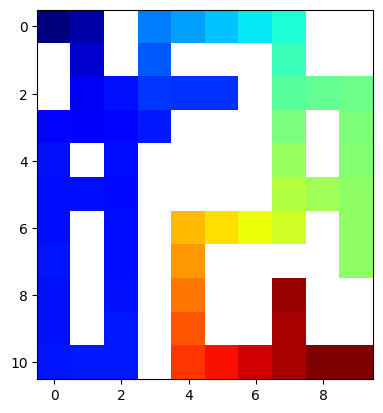

array([-27.62525562, -26.65190753,   0.        , -20.79132404,
       -19.81113517, -18.82996514, -17.84781295, -16.86467763,
         0.        ,   0.        ,   0.        , -25.67758512,
         0.        , -21.77053271,   0.        ,   0.        ,
         0.        , -15.88055818,   0.        ,   0.        ,
         0.        , -24.7022874 , -23.72601342, -22.74876218,
       -22.83438632, -22.81758622,   0.        , -14.89545364,
       -14.6406793 , -14.27599508, -24.04619225, -24.30921825,
       -23.98449352, -23.50497584,   0.        ,   0.        ,
         0.        , -13.909363  ,   0.        , -13.8111429 ,
       -23.71831225,   0.        , -23.80279389,   0.        ,
         0.        ,   0.        ,   0.        , -12.92228529,
         0.        , -13.52620467, -23.81507947, -23.78154022,
       -23.85837861,   0.        ,   0.        ,   0.        ,
         0.        , -11.93421951, -12.5246597 , -13.11889325,
       -23.76974229,   0.        , -23.79257945,   0.  

In [20]:
fig1 = plt.figure(1)
env1.draw_value_info(fig1, agent1.Q)
np.max(agent1.Q, axis =1)

## SARSAエージェントでダンジョンを解くプログラム

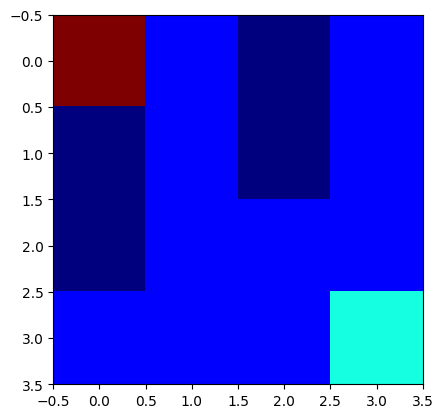

trial =  20  cum_rwd =  -11.0
trial =  40  cum_rwd =  -6.0
trial =  60  cum_rwd =  -9.0
trial =  80  cum_rwd =  -5.0
trial =  100  cum_rwd =  -5.0
trial =  120  cum_rwd =  -5.0
trial =  140  cum_rwd =  -7.0
trial =  160  cum_rwd =  -5.0
trial =  180  cum_rwd =  -5.0
trial =  200  cum_rwd =  -5.0
trial =  220  cum_rwd =  -5.0
trial =  240  cum_rwd =  -5.0
trial =  260  cum_rwd =  -5.0
trial =  280  cum_rwd =  -5.0
trial =  300  cum_rwd =  -5.0
trial =  320  cum_rwd =  -5.0
trial =  340  cum_rwd =  -5.0
trial =  360  cum_rwd =  -5.0
trial =  380  cum_rwd =  -5.0
trial =  400  cum_rwd =  -5.0
trial =  420  cum_rwd =  -5.0
trial =  440  cum_rwd =  -5.0
trial =  460  cum_rwd =  -5.0
trial =  480  cum_rwd =  -5.0
trial =  500  cum_rwd =  -5.0


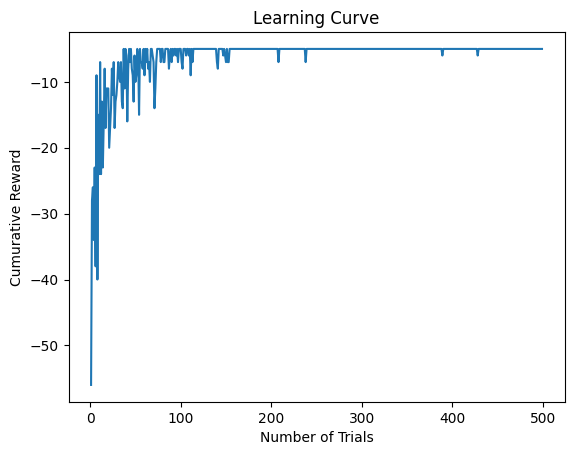

In [23]:
# 最大トライアル数を設定
MaxTrials = 500

# 1トライアルあたりの最大ステップ数（行動選択回数）を設定
MaxSteps = 100

# Figureオブジェクトを作成
fig1 = plt.figure(1)

# 環境のオブジェクトを生成: (T迷路課題からの変更点)
env1 = Dungeon('./simple_map.txt')

# 環境設定を取得する
[num_state, num_action] = env1.get_env_config()

# 学習エージェントオブジェクトを生成
agent1 = SARSAagent(num_state, num_action)

# 学習エージェントのメタパラメータを設定
agent1.set_meta_parameter(alpha=0.1, beta=100.0, gamma=0.999)

# 各トライアルに獲得した累積報酬を格納する変数を初期化
cum_rwd = np.zeros(MaxTrials)

# トライアルをMaxTrials回くり返す
for trial in range(MaxTrials):
    # 過去の状態・行動履歴をリセットする
    agent1.reset_memory()
    # 環境を初期状態に戻し、その状態を取得する
    [rwd, state] = env1.init_state()
    # ゴール状態に到達するまで以下をくり返す
    for step in range(MaxSteps):
        # 現在の状態を表示
        env1.draw_map_info(fig1)
        # ゴール状態に到達できたら、価値関数の更新のみ行う
        if env1.reach_goal():
            agent1.update_value(rwd, state, action)
            break
        # エージェントに現在の状態を伝えて、行動を選択させる
        action = agent1.select_action(state)
        # エージェントの価値関数を更新
        agent1.update_value(rwd, state, action)
        # 選択した行動を環境に出力し、次の状態に遷移させる
        [rwd, state] = env1.move_state(action)
        # 得られた報酬を累積する
        cum_rwd[trial] = cum_rwd[trial] + rwd
    # トライアル後の後処理
    # 20トライアルごとに表示そのエピソードで獲得できた累積報酬を標準出力
    if ((trial+1) % 20) == 0:
        print('trial = ', trial+1, ' cum_rwd = ', cum_rwd[trial])

# 学習曲線の表示
fig2 = plt.figure(2)
ax1 = fig2.add_subplot(1,1,1)
ax1.plot(range(1,trial+1), cum_rwd[0:trial], label = 'raw')
plt.xlabel('Number of Trials')
plt.ylabel('Cumurative Reward')
plt.title('Learning Curve')
plt.show()

### 学習後の価値関数を表示

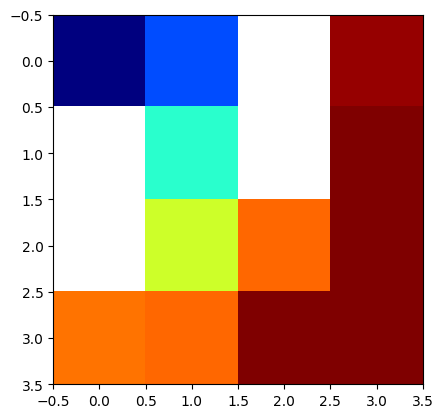

array([-4.99003765, -3.9940071 ,  0.        , -0.1       ,  0.        ,
       -2.99700057,  0.        ,  0.        ,  0.        , -1.9989991 ,
       -0.99999956,  0.        , -1.06605981, -1.        ,  0.        ,
        0.        ])

In [24]:
fig1 = plt.figure(1)
env1.draw_value_info(fig1, agent1.Q)
np.max(agent1.Q, axis =1)